# Karman'sche Wirbelstraße - Finite Elemente mit DUNE

In [2]:
import dune
import numpy as np
import pygmsh
import ufl
from dune import fem
from dune.alugrid import aluConformGrid as leafGridView
from dune.common import comm
from dune.fem.space import lagrange, dgonb
from dune.grid import cartesianDomain
from matplotlib import pyplot as plt
#from tqdm import tqdm

In [12]:
domain = cartesianDomain([0,0], [1,1], [8,8])
gridView = leafGridView(domain)
vtk = gridView.sequencedVTK("struct_grid_refine")
vtk()
gridView.hierarchicalGrid.globalRefine(1)
vtk()
gridView.hierarchicalGrid.globalRefine(1)
vtk()
gridView.hierarchicalGrid.globalRefine(1)
vtk()
gridView.hierarchicalGrid.globalRefine(1)
vtk()
gridView.hierarchicalGrid.globalRefine(1)
vtk()

In [2]:
# import pygmsh
from gmsh2dgf import gmsh2DGF
from dune.grid import reader as gridReader

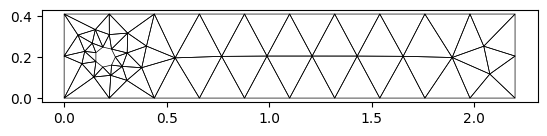

In [20]:
order = 2
t_end = 10
with pygmsh.occ.Geometry() as geom:
    # Domain size
    L, H = 2.2, 0.41
    r = 0.05
    rectangle = geom.add_rectangle([0.0, 0.0, 0.0], L, H)
    cylinder = geom.add_disk([0.2, 0.2, 0.0], r)
    domain = geom.boolean_difference([rectangle], [cylinder])
    mesh = geom.generate_mesh()
    points, cells = mesh.points, mesh.cells_dict
    domain = {
        "vertices": points[:, :2].astype(float),
        "simplices": cells["triangle"].astype(int),
    }
lb_method = 9 
gridView = leafGridView(domain, dimgrid=2, lbMethod=lb_method)
vortex_street_grid.plot()
# vtk = vortex_street_grid.sequencedVTK("karman_grid")
# vtk()

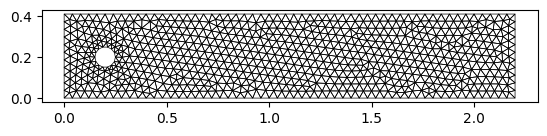

In [21]:
order = 2
coarse = False
with pygmsh.occ.Geometry() as geom:
    radius2 = lambda x , y : (x - 0.2)**2 + (y - 0.2)**2
    outsideSize = 0.25 if coarse else 0.04 # 0.1 coarse
    insideSize = lambda x , y : 0.02 + 1.5*radius2 (x, y)
    geom.set_mesh_size_callback(lambda dim, tag, x, y, z, lc: min(insideSize(x,y),outsideSize))
    rectangle = geom.add_rectangle ([0 , 0 , 0 ] , 2.2 , 0.41)
    cylinder = geom.add_disk([0.2, 0.2, 0.0], 0.05)
    geom.boolean_difference(rectangle, cylinder)
    mesh = geom.generate_mesh()
    points, cells = mesh.points, mesh.cells_dict
    # extract dictionary for grid construction
    domain = {"vertices": points [:, :2].astype(float), "simplices": cells["triangle"].astype(int)}
gridView = leafGridView(domain, dimgrid=2)
gridView.plot()
# vtk = gridView.sequencedVTK("karman_grid1_")
# vtk()

DUNE-INFO: Compiling UFLLocalFunction (new)
DUNE-INFO: Compiling GridViewIndexSet (new)
DUNE-INFO: Compiling boundaryId( Dune::ALUGrid< 2, 2, Dune::simplex >::LeafGridView &, Dune::ALUGrid< 2, 2, Dune::simplex >::LeafGridView::Intersection & ) (new)


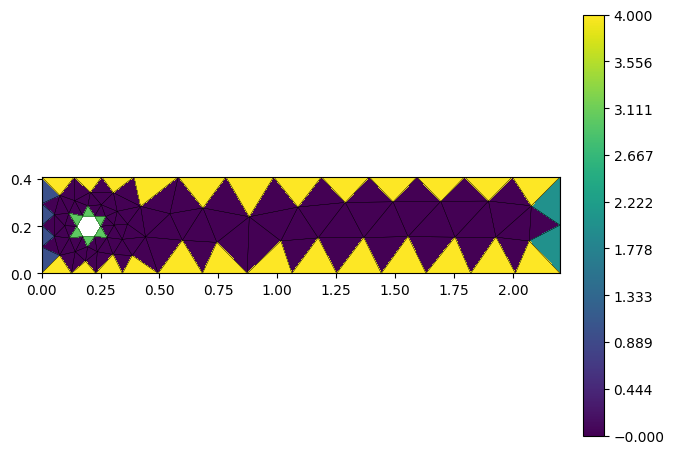

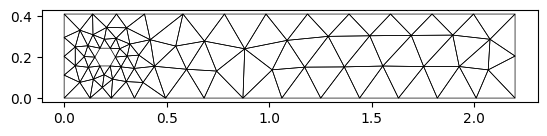

In [4]:
from gmsh2dgf import gmsh2DGF, projectBoundaryIds
from dune.grid import reader as gridReader

H = 0.41
L = 2.2
C = [0.2, 0.2]
R = 0.05
eps = 1e-10
maxH = R # 0.02

with pygmsh.geo.Geometry() as geom:
    geom.set_mesh_size_callback(lambda dim, tag, x, y, z, lc:
        min(maxH + 1.5*( (x-0.2)**2+(y-0.2)**2), H / 2.0)
    )
    obstacle = geom.add_circle([*C, 0.0], R, make_surface=False)
    domain = geom.add_rectangle(0, L, 0, H, 0, holes=[obstacle.curve_loop])
    geom.add_physical(domain, 'domain')
    geom.add_physical(obstacle.curve_loop.curves, 'obstacle')
    mesh = geom.generate_mesh(dim=2)
    points, cells = mesh.points, mesh.cells_dict
    boundaryDomains = {
        1: [[0.0-eps, 0.0-eps], [0.0+eps, H+eps]], # bbox inflow
        2: [[L-eps, 0.0-eps], [L+eps, H+eps]], # bbox outflow
        3: [[C[0]-R-eps, C[1]-R-eps], [C[0]+R+eps, C[1]+R+eps]], # bbox hole
        4: "default", # top and bottom
    }
    dgf = gmsh2DGF(points, cells, bndDomain=boundaryDomains, dim=2)
    obstacleFacets = mesh.cells[0].data[mesh.cell_sets['obstacle'][0]]
    dgf += f'''
Projection
function d(x) = x - {C}
function p(x) = {R} * d(x) / |d(x)| + {C}
'''
    for facet in obstacleFacets:
        dgf += f'''segment {facet[0]} {facet[1]} p
'''
    dgf += '''
#

GridParameter
Name ChannelWithHole
RefinementEdge longest
bisectioncompatibility 1
#
'''
domain = (gridReader.dgfString, dgf)
gridView = leafGridView(domain, dimgrid=2)
#vtk = gridView.sequencedVTK("karman_grid_")
#vtk()

bndIds = projectBoundaryIds( gridView )
fig = plt.figure()
bndIds.plot(figure=fig)
plt.savefig('grid_boundry1.png', dpi=300)
gridView.plot()

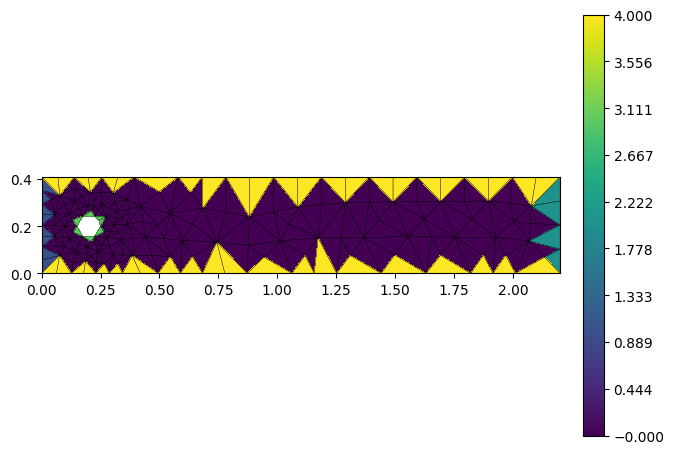

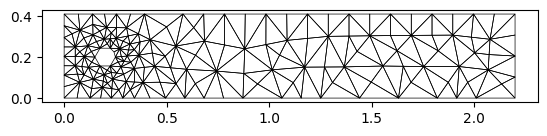

In [5]:
gridView.hierarchicalGrid.globalRefine(1)
bndIds = projectBoundaryIds( gridView )
fig = plt.figure()
bndIds.plot(figure=fig)
plt.savefig('grid_boundry2.png', dpi=300)
gridView.plot()

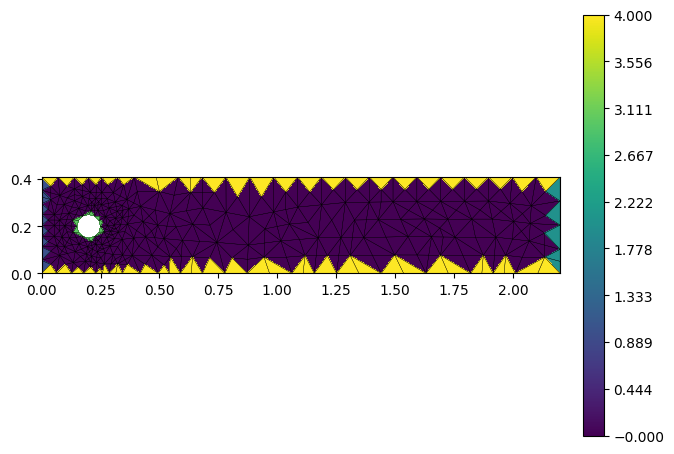

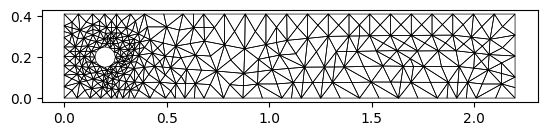

In [6]:
gridView.hierarchicalGrid.globalRefine(1)
#vtk()
bndIds = projectBoundaryIds( gridView )
fig = plt.figure()
bndIds.plot(figure=fig)
plt.savefig('grid_boundry3.png', dpi=300)
gridView.plot()

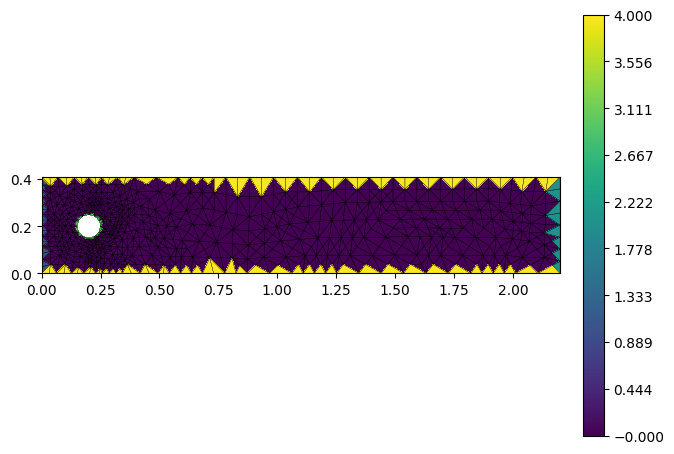

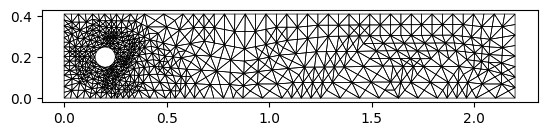

In [7]:
gridView.hierarchicalGrid.globalRefine(1)
bndIds = projectBoundaryIds( gridView )
fig = plt.figure()
bndIds.plot(figure=fig)
plt.savefig('grid_boundry4.png', dpi=300)
gridView.plot()